# Linear elasticity with full order and reduced order simulation

## Environment Setup

### Directory

In [1]:
import sys
from pathlib import Path
import importlib

# -----------------------------------------------------------------------------
# Project-root auto-detection script
# Ensures the top-level directory (containing 'src/' and 'tests/')
# is on Python's import path, allowing modules to be imported consistently
# regardless of the current working directory (e.g., in notebooks).
# -----------------------------------------------------------------------------

# 1) Start from the current working directory (or notebook location)
notebook_path = Path().resolve()
PROBLEM_NAME = notebook_path.name

linear_dir = notebook_path.parent     # .../linear
# 2) Traverse upward through parent directories to find the project root
for parent in notebook_path.parents:
    # Check for indicators of the project's root structure
    if (parent / "src").exists() and (parent / "tests").exists():
        project_root = parent
        break
else:
    # If loop completes without break, no valid root was found
    raise RuntimeError(
        "Could not find project root containing 'src' and 'tests'"
    )

# 3) Prepend the detected root to sys.path to prioritize local modules
sys.path.insert(0, str(project_root))

if str(linear_dir) not in sys.path:
    sys.path.insert(0, str(linear_dir))
    
# 4) Confirm successful addition (optional print for debugging)
print("Project root added to sys.path:", project_root)

Project root added to sys.path: D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom


### Standard Imports

In [2]:
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.visualization.generate_vtk import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est_t import *
import skrom.problem_classes.static.master_class as master
from skrom.utils.visualization.generate_vtk import save_vtk_solution

PETSc available: True


In [3]:
# Register problem (runs @register_problem)
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def")

In [4]:
import sci_mplstyle_package

## Full Order Simulation

In [5]:
generate =True

if generate:
    sim = master.fom_simulation(num_snapshots=2**3)
    sim.run_simulation()

Snap 1/16 params=[5.96246899e+06 3.46764054e-01]
Snap 2/16 params=[8.82664322e+06 2.35362614e-01]
Snap 3/16 params=[7.51200249e+06 3.75247216e-01]
Snap 4/16 params=[3.77282223e+06 2.92801616e-01]
Snap 5/16 params=[4.47792003e+06 3.63751185e-01]
Snap 6/16 params=[6.91843261e+06 2.55474171e-01]
Snap 7/16 params=[9.98220526e+06 3.07871534e-01]
Snap 8/16 params=[4.91669917e+06 2.22300364e-01]
Snap 9/16 params=[5.2366285e+06 2.1066098e-01]
Snap 10/16 params=[6.53580163e+06 3.86180237e-01]
Snap 11/16 params=[8.49500844e+06 2.98394355e-01]
Snap 12/16 params=[3.66832519e+06 3.23520532e-01]
Snap 13/16 params=[4.63980554e+06 2.66989122e-01]
Snap 14/16 params=[9.43908267e+06 3.42444124e-01]
Snap 15/16 params=[7.45088362e+06 2.29621144e-01]
Snap 16/16 params=[6.12430812e+06 3.54689506e-01]
Saved full-order solution → fos_solutions.npy
Saved ROM data             → ROM_simulation_data.npz


### Load Simulation data

In [6]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\dynamic\linear\problem_beam_vibration_3d\ROM_data


## Data Generation

### Generate Training Solution Dataset

In [7]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap = len(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


16


### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = LS_train[:,0:1,:] #np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Vizualize Parameters

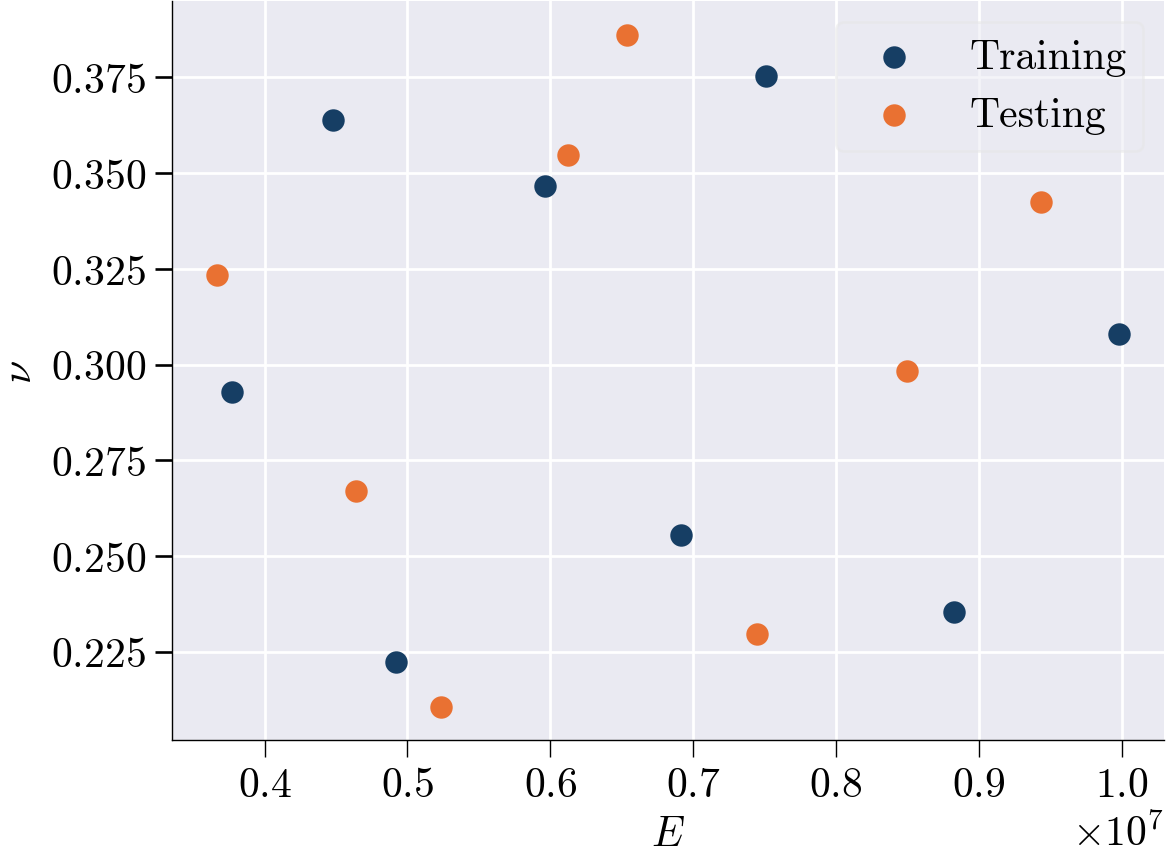

In [9]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:N_snap//2][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:N_snap//2][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[N_snap//2:][:, 0],    # First parameter (μ) for testing samples
           param_list[N_snap//2:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$E$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\nu$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on solution snapshots

In [10]:
B = np.vstack([LS_train_ms[i] for i in range(LS_train_ms.shape[0])])  # (20000,3075)

Number of modes selected: 90


Text(0.5, 0, 'POD modes ($k$)')

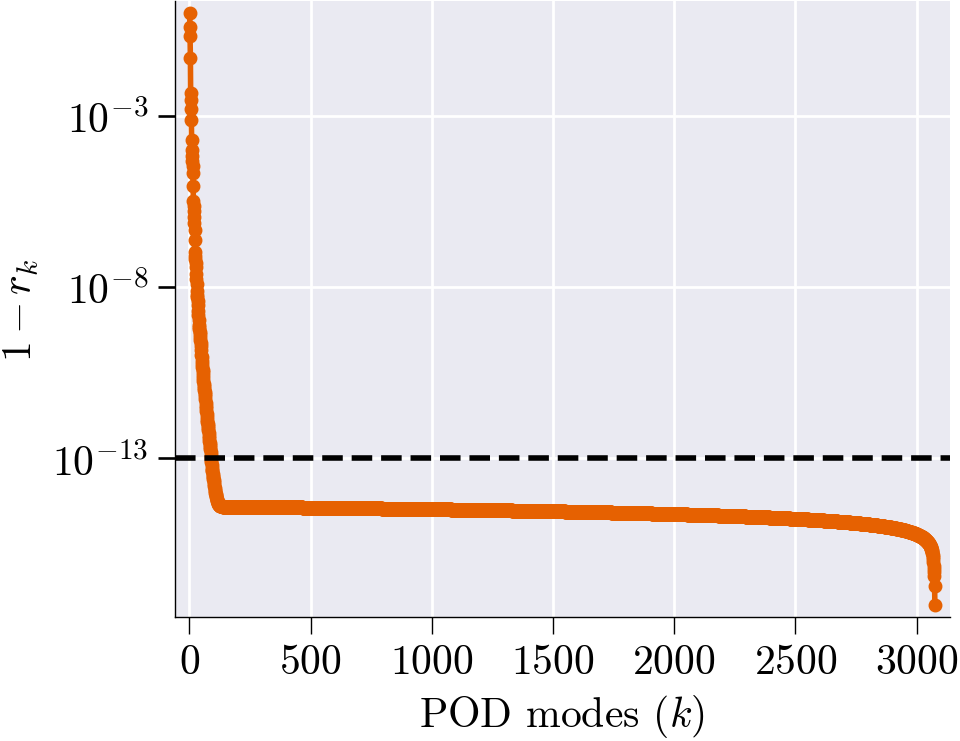

In [11]:
# fig, ax = plt.subplots(figsize=(5,3.5))
plt.rcParams['lines.markersize'] = 6
plt.rcParams['lines.linewidth'] = 2.0

n_sel, U = svd_mode_selector(B, tolerance = 1e-13, modes=True)
V_sel = U[:, :n_sel]
plt.ylabel('$1-r_{k}$')
plt.xlabel('POD modes ($k$)')

In [12]:
V_sel.shape

(3075, 90)

## ROM Simulation

In [13]:
#Run ROM simulation here:

rom = master.rom_simulation(V_sel = V_sel, train_ref= LS_train_mean[0])

[load_rom_data] loaded from d:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\dynamic\linear\problem_beam_vibration_3d\ROM_data


In [14]:
rom.run_rom_simulation();

Snap 1/16 params=[5.2366285e+06 2.1066098e-01]
Snap 2/16 params=[6.53580163e+06 3.86180237e-01]
Snap 3/16 params=[8.49500844e+06 2.98394355e-01]
Snap 4/16 params=[3.66832519e+06 3.23520532e-01]
Snap 5/16 params=[4.63980554e+06 2.66989122e-01]
Snap 6/16 params=[9.43908267e+06 3.42444124e-01]
Snap 7/16 params=[7.45088362e+06 2.29621144e-01]
Snap 8/16 params=[6.12430812e+06 3.54689506e-01]


In [15]:
#Assign values for the statistics
LS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up#[1:]
ROM_relative_error = rom.rom_error

### ROM Solution vs Full order statistics

In [16]:
# --- ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)


In [17]:
# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)


ROM Accuracy Report

Global Errors:
L2 Error:                        1.2609e-01
Relative L2 Error:               3.4547e-04
L∞ Error:                        3.1244e-04
Relative L∞ Error:               2.3988e-04
RMSE:                            1.7976e-05
MAE:                             4.6624e-06

Statistical Fit:
R² Score:                        1.0000
Explained Variance:              1.0000

Error Distribution (absolute):
Median Abs Error:                2.1308e-07
95th Percentile Abs Error:       2.3151e-05

Time/Parameter-Dependent Errors:
Average Relative L2 over samples:        3.5370e-04
Max Relative L2 over samples:            4.4200e-03
Min Relative L2 over samples:            0.0000e+00
————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————


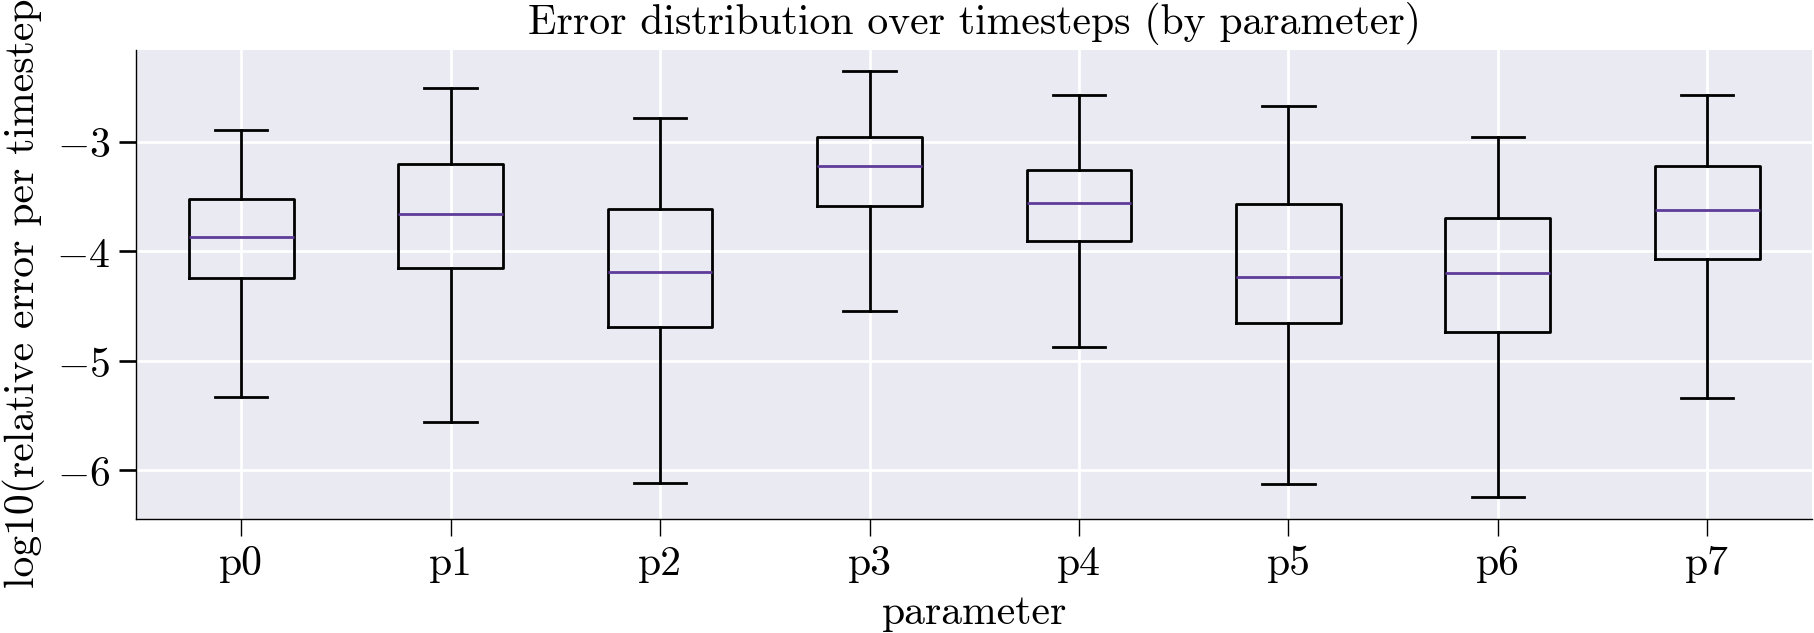

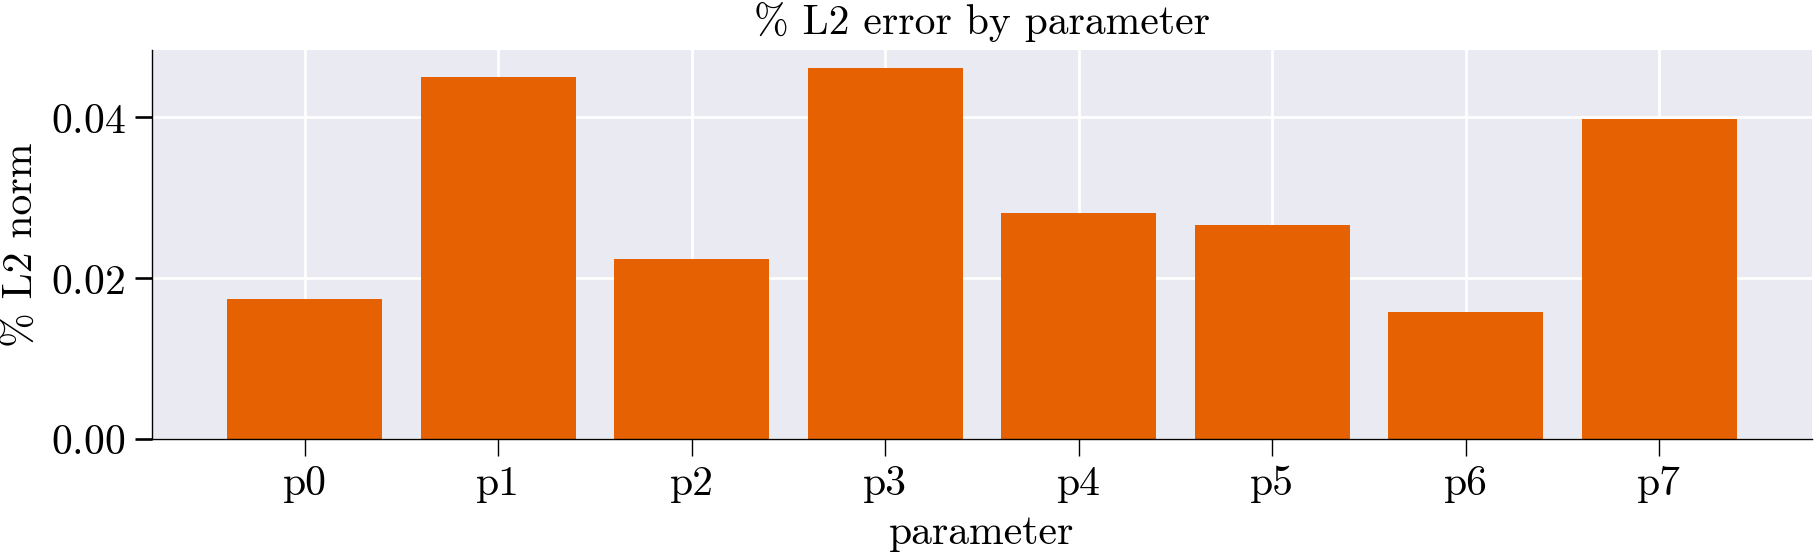

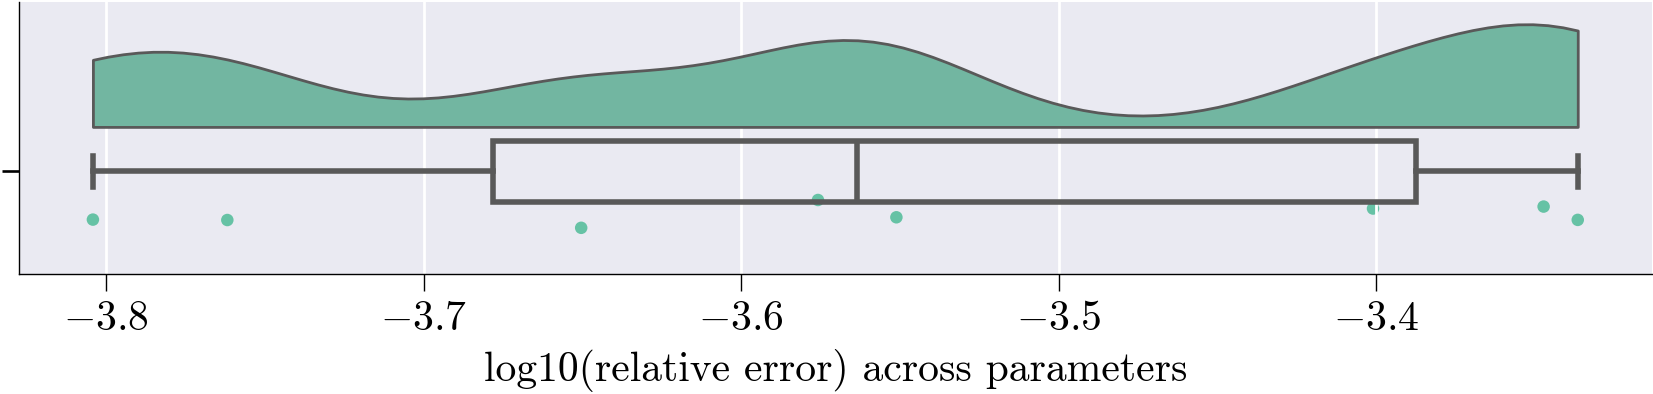

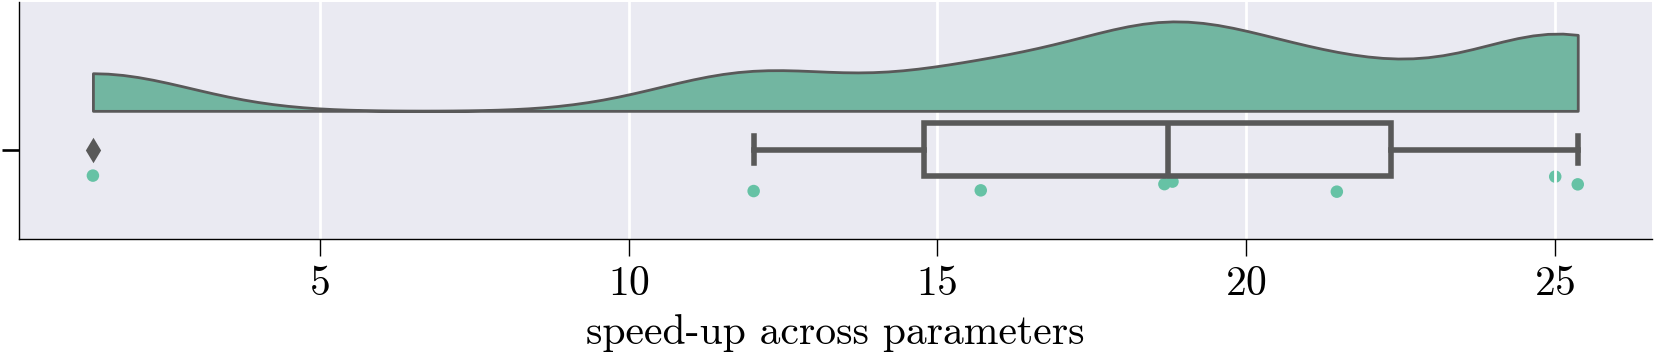

In [18]:
out = plot_rom_param_diagnostics_t(
    LS_test,
    LS_rom,
    l2_per_param=ROM_relative_error,          # (p,)
    speedup_per_param=ROM_speed_up, # (p,)
    param_labels=[f"p{i}" for i in range(LS_test.shape[0])],
    use_raincloud=True,
)


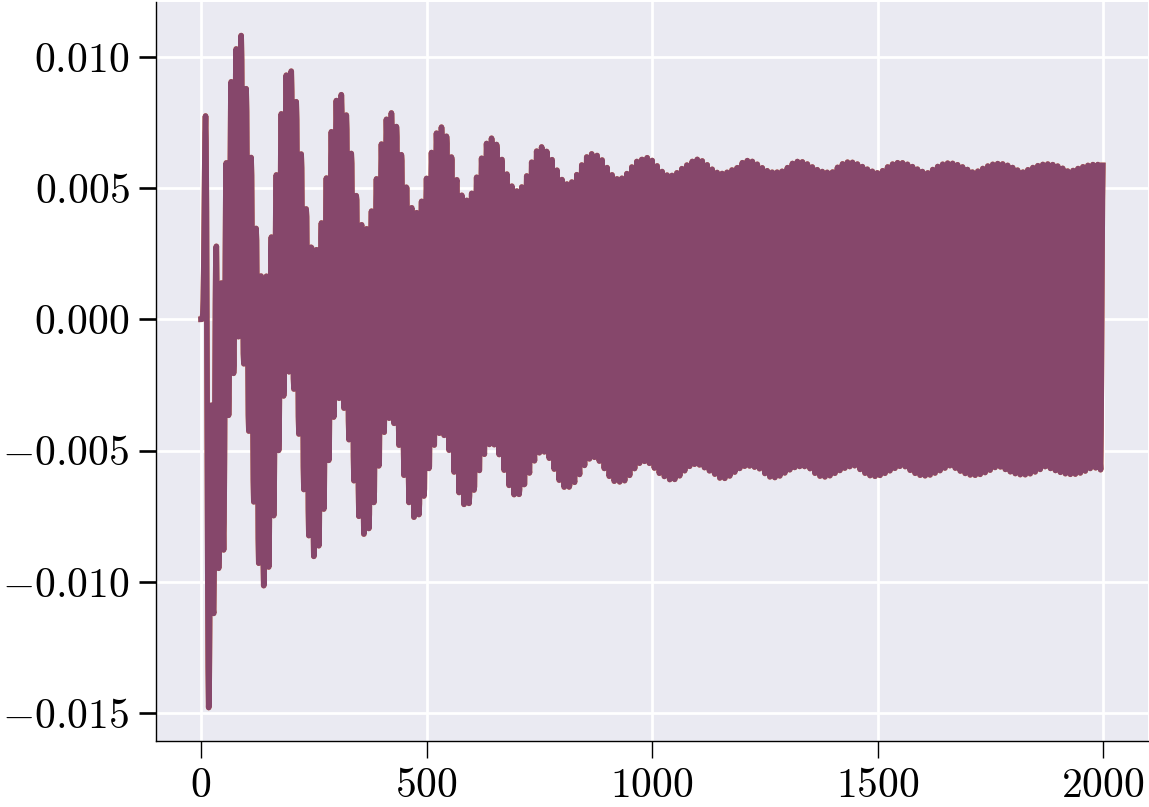

In [19]:
plt.plot(LS_test[0][:,100])
plt.plot(LS_rom[0][:,100],alpha=0.7)


## Visualize on paraview 

In [20]:
save_vtk_time_series(
    LS_rom[0].T, np.linspace(0,40,2000),
    sim_data['mesh'].item(), sim_data['basis'].item(),
    scale = 1e0,
    run_dir=Path("results/anim_rom"),
    prefix="beam"
)

In [21]:
save_vtk_time_series(
    LS_test[0].T, np.linspace(0,40,2000),
    sim_data['mesh'].item(), sim_data['basis'].item(),
    scale = 1e0,
    run_dir=Path("results/anim_fom"),
    prefix="beam"
)